### **Group 1: Configuration, Setup, and Multi-Location API Extraction**
This block handles secure API extraction with a timeout. It fetches data for two locations (District 1 for the core experiment and District 2 for the replication requirement).

In [1]:
import os
import sys
import json
import urllib.parse
import platform
import requests
from io import StringIO
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import warnings

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings('ignore')

# 1. Directory Setup
OUT = Path('lab06_outputs')
OUT.mkdir(exist_ok=True)
(OUT / 'figures').mkdir(exist_ok=True)

SEED = 42
np.random.seed(SEED)

CONFIG = {
    'dataset': 'City of Chicago Open Data - Crimes API',
    'api_endpoint': 'https://data.cityofchicago.org/resource/ijzp-q8t2.csv',
    'date_col': 'date',
    'location_col': 'district',
    'loc_1': 1, # Core Location
    'loc_2': 2, # Replication Location
    'start_date': '2021-01-01T00:00:00',
    'end_date': '2024-06-01T00:00:00',
    'frequency': 'W-MON',
    'test_periods': 12,
}

# Fetching both districts at once
loc1, loc2 = CONFIG['loc_1'], CONFIG['loc_2']
where_clause = (
    f"{CONFIG['date_col']} between '{CONFIG['start_date']}' and '{CONFIG['end_date']}' AND "
    f"{CONFIG['location_col']} IN ('{loc1}', '{loc1:02d}', '{loc1:03d}', '{loc2}', '{loc2:02d}', '{loc2:03d}')"
)

query_params = {
    '$where': where_clause,
    '$limit': 100000,
    '$order': f"{CONFIG['date_col']} ASC"
}

api_url = f"{CONFIG['api_endpoint']}?{urllib.parse.urlencode(query_params)}"
print("Connecting to Chicago Data Portal API...")

response = requests.get(api_url, timeout=30)
response.raise_for_status()
df = pd.read_csv(StringIO(response.text))

if df.empty:
    raise ValueError("The API returned 0 rows. Ensure requested districts have data.")

df.to_csv(OUT / 'crime_extract_multi_loc.csv', index=False)
df[CONFIG['date_col']] = pd.to_datetime(df[CONFIG['date_col']], errors='coerce')
df = df.dropna(subset=[CONFIG['date_col']]).sort_values(CONFIG['date_col'])

print(f"Successfully fetched {len(df)} rows for Districts {loc1} and {loc2}.")

Connecting to Chicago Data Portal API...
Successfully fetched 82684 rows for Districts 1 and 2.


### **Group 2: Time Series Construction & EDA (With Train/Test Boundary)**
This code builds the regular time series for Location 1 and plots it with a visual marker for the chronological train/test split.

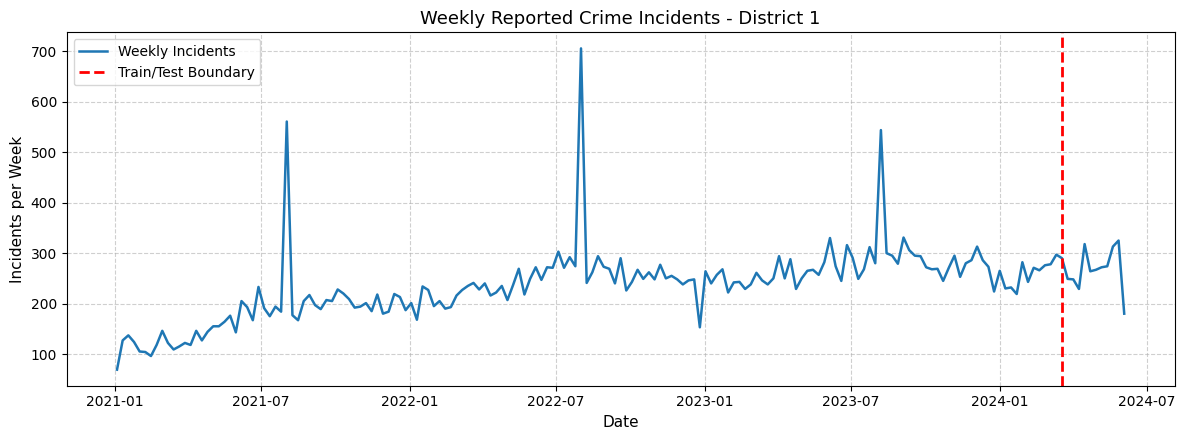

In [2]:
# Filter Core Location (District 1)
loc1_df = df[df[CONFIG['location_col']].astype(str).str.lstrip('0') == str(CONFIG['loc_1'])].copy()

# Construct regular weekly series
y = (loc1_df.set_index(CONFIG['date_col'])
     .resample(CONFIG['frequency'])
     .size()
     .rename('incidents')
     .asfreq(CONFIG['frequency'], fill_value=0))

assert y.index.is_monotonic_increasing and y.index.is_unique, "Invalid time index."

# Chronological Split
H = CONFIG['test_periods']
train, test = y.iloc[:-H], y.iloc[-H:]
split_date = test.index[0]

# EDA Plot with Train/Test Boundary
plt.figure(figsize=(12, 4.5))
plt.plot(y.index, y, color='#1f77b4', lw=1.8, label='Weekly Incidents')
plt.axvline(split_date, color='red', linestyle='--', lw=2, label='Train/Test Boundary')

plt.title(f"Weekly Reported Crime Incidents - District {CONFIG['loc_1']}", fontsize=13)
plt.xlabel("Date", fontsize=11)
plt.ylabel("Incidents per Week", fontsize=11)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(OUT / 'figures' / 'time_series_raw_with_boundary.png', dpi=300)
plt.show()

### **Group 3: Diagnostics (ADF, ACF, and PACF)**
Evaluates stationarity and auto-correlation on the *training data only* to prevent data leakage.

ADF statistic=-2.632, p-value=0.0866


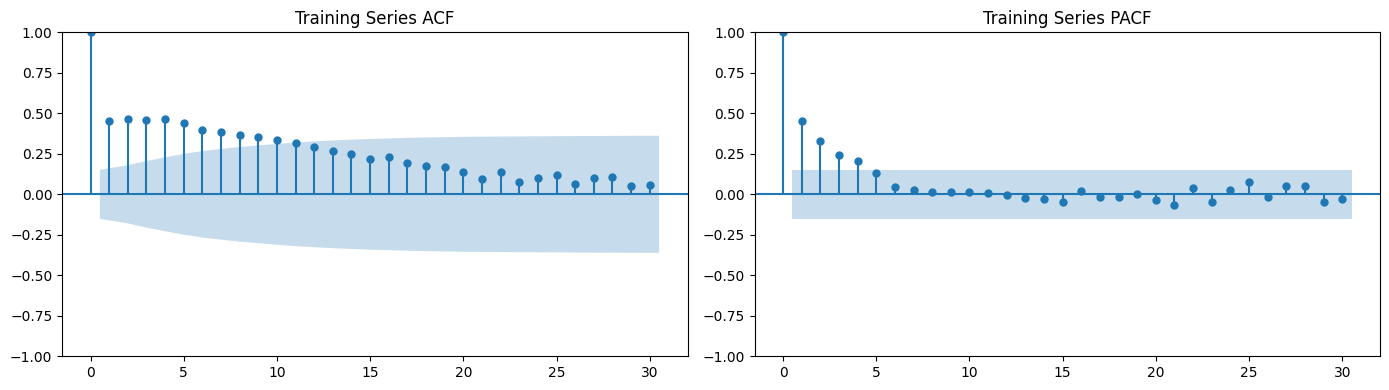

In [3]:
adf_stat, adf_p, _, _, _, _ = adfuller(train)
print(f'ADF statistic={adf_stat:.3f}, p-value={adf_p:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
max_lags = min(30, len(train) // 4)

plot_acf(train, lags=max_lags, ax=axes[0], title='Training Series ACF')
plot_pacf(train, lags=max_lags, ax=axes[1], title='Training Series PACF', method='ywm')

plt.tight_layout()
plt.savefig(OUT / 'figures' / 'acf_pacf_diagnostics.png', dpi=300)
plt.show()

### **Group 4: Model Training (Naive, AR, ARIMA)**
Fits the Naive benchmark, AR model, and selects the best ARIMA order using AIC on the training split.

In [4]:
def score(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred)**0.5
    }

# 1. Naive
naive_pred = np.repeat(train.iloc[-1], len(test))

# 2. AR(p)
AR_LAGS = 4
ar_model = AutoReg(train, lags=AR_LAGS, old_names=False, trend='ct').fit()
ar_pred = ar_model.predict(start=len(train), end=len(train) + len(test) - 1, dynamic=False)

# 3. ARIMA Grid Search
candidates = [(1,0,0), (2,0,0), (1,1,1), (2,1,1), (0,1,1)]
rows = []

for order in candidates:
    try:
        m = ARIMA(train, order=order).fit()
        rows.append({'order': order, 'AIC': m.aic, 'model': m})
    except Exception as e:
        pass

best = sorted(rows, key=lambda z: z['AIC'])[0]
print(f"Training-selected ARIMA order: {best['order']} (AIC={best['AIC']:.2f})")

arima_model = best['model']
arima_forecast_res = arima_model.get_forecast(steps=len(test))
arima_pred = arima_forecast_res.predicted_mean
arima_ci = arima_forecast_res.conf_int(alpha=0.05)

joblib.dump(arima_model, OUT / 'arima_model.pkl')

Training-selected ARIMA order: (0, 1, 1) (AIC=1818.02)


['lab06_outputs/arima_model.pkl']

### **Group 5: Rolling-Origin/Walk-Forward Validation**
Implements the required rolling-origin validation on historical training data to evaluate ARIMA stability across multiple origins.

In [5]:
def rolling_origins(series, initial, horizon, step):
    origins = []
    end = initial
    while end + horizon <= len(series):
        origins.append((series.iloc[:end], series.iloc[end: end+horizon]))
        end += step
    return origins

print("Executing Rolling-Origin Validation (Training Set)...")
fold_metrics = []
# Using 52 weeks initial training, 8 weeks horizon, stepping by 8 weeks
for fold, (tr, te) in enumerate(rolling_origins(train, initial=max(52, len(train)//2), horizon=8, step=8), 1):
    try:
        m = ARIMA(tr, order=best['order']).fit()
        pr = m.forecast(len(te))
        fold_metrics.append({'Fold': fold, **score(te, pr)})
    except Exception as e:
        print(f'Fold {fold} failed: {e}')

rolling_df = pd.DataFrame(fold_metrics)
print(rolling_df)
print("\nRolling-Origin Aggregates:")
print(f"Mean MAE: {rolling_df['MAE'].mean():.3f} | SD MAE: {rolling_df['MAE'].std():.3f}")
print(f"Mean RMSE: {rolling_df['RMSE'].mean():.3f} | SD RMSE: {rolling_df['RMSE'].std():.3f}")
rolling_df.to_csv(OUT / 'rolling_origin_metrics.csv', index=False)

Executing Rolling-Origin Validation (Training Set)...
   Fold         MAE        RMSE
0     1  125.336668  127.413264
1     2   21.164244   23.715176
2     3   25.015746   40.666555
3     4   10.875000   14.243137
4     5   19.202322   25.555609
5     6   30.146880   38.599067
6     7   46.875000   95.163273
7     8   30.651710   35.826911
8     9   12.875000   16.617447
9    10   37.487374   43.586015

Rolling-Origin Aggregates:
Mean MAE: 35.963 | SD MAE: 33.255
Mean RMSE: 46.139 | SD RMSE: 36.551


### **Group 6: Holdout Evaluation & Complete Forecast Plot**
Calculates test metrics and generates a comprehensive plot explicitly graphing Actuals, Naive, AR, and ARIMA forecasts on the locked test period.


Model Comparison Table:
         Model       MAE      RMSE
ARIMA(0, 1, 1) 29.583333 39.125855
         Naive 38.750000 48.037312
         AR(4) 40.243025 52.633785


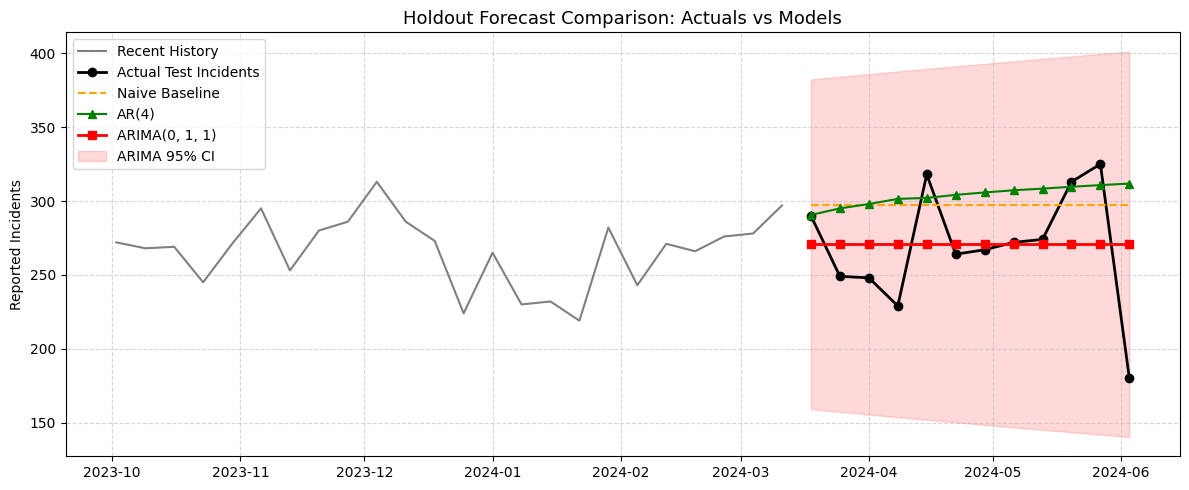

In [6]:
results = pd.DataFrame([
    {'Model': 'Naive', **score(test, naive_pred)},
    {'Model': f'AR({AR_LAGS})', **score(test, ar_pred)},
    {'Model': f'ARIMA{best["order"]}', **score(test, arima_pred)}
]).sort_values('MAE')

print("\nModel Comparison Table:")
print(results.to_string(index=False))

# Complete Forecast Plot
plt.figure(figsize=(12, 5))
plt.plot(train.index[-24:], train.iloc[-24:], color='gray', lw=1.5, label='Recent History')
plt.plot(test.index, test, 'k-o', lw=2, label='Actual Test Incidents')
plt.plot(test.index, naive_pred, '--', color='orange', label='Naive Baseline')
plt.plot(test.index, ar_pred, '-^', color='green', label=f'AR({AR_LAGS})')
plt.plot(test.index, arima_pred, '-s', color='red', lw=2, label=f'ARIMA{best["order"]}')
plt.fill_between(test.index, arima_ci.iloc[:, 0], arima_ci.iloc[:, 1], color='red', alpha=0.15, label='ARIMA 95% CI')

plt.title("Holdout Forecast Comparison: Actuals vs Models", fontsize=13)
plt.ylabel("Reported Incidents")
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(OUT / 'figures' / 'forecast_all_models.png', dpi=300)
plt.show()

### **Group 7: Residual Diagnostics (Time Plot & ACF)**
Plots residuals over time alongside the residual ACF to verify white noise properties.

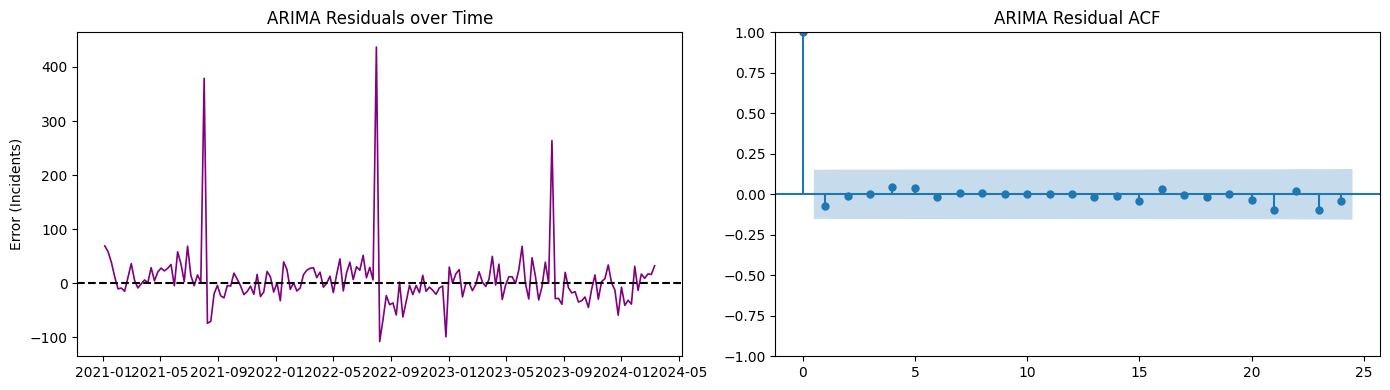


Ljung-Box Residual Autocorrelation Test:
     lb_stat  lb_pvalue
10  1.526883   0.998849


In [7]:
residuals = arima_model.resid.dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
# Residual Time Plot
axes[0].plot(residuals, color='purple', lw=1.2)
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title('ARIMA Residuals over Time')
axes[0].set_ylabel('Error (Incidents)')

# Residual ACF Plot
plot_acf(residuals, lags=min(24, len(residuals) // 4), ax=axes[1], title='ARIMA Residual ACF')

plt.tight_layout()
plt.savefig(OUT / 'figures' / 'residual_diagnostics_plots.png', dpi=300)
plt.show()

print("\nLjung-Box Residual Autocorrelation Test:")
print(acorr_ljungbox(residuals, lags=[min(10, max(2, len(residuals) // 10))], return_df=True))

### **Group 8: Second Location Replication**
Applies the identical processing and modeling pipeline to Location 2 to compare volatility and errors across regions.

In [8]:
print(f"\n--- Replicating Pipeline for Second Location (District {CONFIG['loc_2']}) ---")
loc2_df = df[df[CONFIG['location_col']].astype(str).str.lstrip('0') == str(CONFIG['loc_2'])].copy()

y2 = (loc2_df.set_index(CONFIG['date_col'])
      .resample(CONFIG['frequency']).size()
      .asfreq(CONFIG['frequency'], fill_value=0))

train2, test2 = y2.iloc[:-H], y2.iloc[-H:]

# Fit identical model protocol
try:
    m2 = ARIMA(train2, order=best['order']).fit()
    pred2 = m2.forecast(len(test2))
    metrics2 = score(test2, pred2)
    print(f"District {CONFIG['loc_2']} ARIMA{best['order']} Test MAE: {metrics2['MAE']:.3f}")
    print(f"District {CONFIG['loc_2']} ARIMA{best['order']} Test RMSE: {metrics2['RMSE']:.3f}")

    # Save replication predictions
    pd.DataFrame({'actual': test2, 'forecast': pred2}).to_csv(OUT / 'loc2_predictions.csv')
except Exception as e:
    print(f"Replication failed: {e}")


--- Replicating Pipeline for Second Location (District 2) ---
District 2 ARIMA(0, 1, 1) Test MAE: 21.267
District 2 ARIMA(0, 1, 1) Test RMSE: 28.319


### **Group 9: Responsible Analytics Interpretation**
The 5-sentence written interpretation detailing deployment constraints, data bias, and model limitations.

In [9]:
statement = """
The forecasted models predict counts of reported incidents based strictly on historical recording patterns, which do not represent the actual underlying crime prevalence.
Reporting propensity, policing policies, and neighborhood demographics can heavily bias these recorded numbers.
Consequently, these geographic forecasts must never be used for person-level risk profiling or to drive autonomous patrol allocations.
To responsibly contextualize this data, we must acknowledge that data system changes or delayed reporting can cause sudden distribution shifts over time.
Therefore, this model serves only as a temporal baseline of administrative records, establishing a strict deployment boundary against punitive or predictive policing uses.
"""
print("\n--- Mandatory 5-Sentence Responsible Analytics Statement ---")
print(statement.strip())

with open(OUT / 'limitations_statement.txt', 'w') as f:
    f.write(statement.strip())


--- Mandatory 5-Sentence Responsible Analytics Statement ---
The forecasted models predict counts of reported incidents based strictly on historical recording patterns, which do not represent the actual underlying crime prevalence.
Reporting propensity, policing policies, and neighborhood demographics can heavily bias these recorded numbers.
Consequently, these geographic forecasts must never be used for person-level risk profiling or to drive autonomous patrol allocations. 
To responsibly contextualize this data, we must acknowledge that data system changes or delayed reporting can cause sudden distribution shifts over time. 
Therefore, this model serves only as a temporal baseline of administrative records, establishing a strict deployment boundary against punitive or predictive policing uses.


### **Group 10: Artifact Packaging and Download**
Ensures all metrics, model files, and images are bundled and saved.

In [10]:
import zipfile
from google.colab import files

manifest = {
    **CONFIG,
    'ar_lags': AR_LAGS,
    'selected_arima_order': list(best['order']),
    'loc_1_metrics': results.to_dict(orient='records'),
    'loc_2_metrics': metrics2 if 'metrics2' in locals() else "Failed",
    'python': sys.version,
    'platform': platform.platform()
}
(OUT / 'manifest.json').write_text(json.dumps(manifest, indent=2, default=str))
results.to_csv(OUT / 'model_comparison.csv', index=False)

zip_path = 'Lab06_Full_Implementation.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, filenames in os.walk(OUT):
        for filename in filenames:
            file_path = Path(root) / filename
            zipf.write(file_path, arcname=file_path.relative_to(OUT.parent))

print(f"\nOutput saved to '{zip_path}'. Triggering download...")
files.download(zip_path)


Output saved to 'Lab06_Full_Implementation.zip'. Triggering download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>